In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"christopherjeng","key":"0f2296e8456347ee0416ed64eea93d9a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d prajwalbhamere/car-damage-severity-dataset

Dataset URL: https://www.kaggle.com/datasets/prajwalbhamere/car-damage-severity-dataset
License(s): CC-BY-NC-SA-4.0
car-damage-severity-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/car-damage-severity-dataset.zip -d Car_Damage_Severity_Dataset

Archive:  /content/car-damage-severity-dataset.zip
replace Car_Damage_Severity_Dataset/data3a/training/01-minor/0001.JPEG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
data_path = 'Car_Damage_Severity_Dataset'
print(os.listdir(data_path))

['data3a']


In [ ]:
import os
import torch
from torch import nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [ ]:
from torchvision import transforms

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to 224x224
    transforms.ToTensor(),          # Convert to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize like ImageNet
                         std=[0.229, 0.224, 0.225])
])

dataset_train = ImageFolder('/content/Car_Damage_Severity_Dataset/data3a/training', transform=transform)
dataset_val   = ImageFolder('/content/Car_Damage_Severity_Dataset/data3a/validation', transform=transform)

combined_dataset = ConcatDataset([dataset_train, dataset_val])

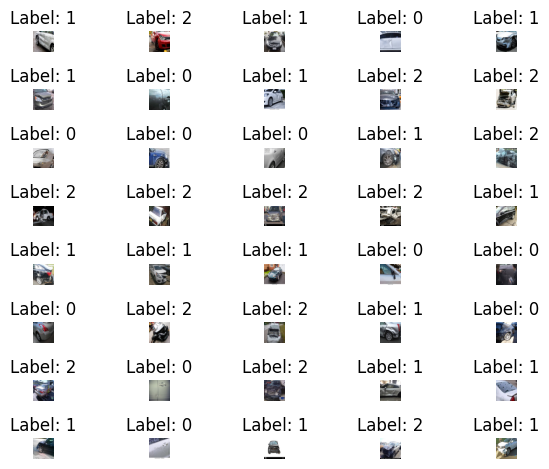

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import random
import torch

def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

# # of images
num_images = 40
random_indices = random.sample(range(len(combined_dataset)), num_images)

# Ploting
for i, idx in enumerate(random_indices):
    image, label = combined_dataset[idx]

    image = unnormalize(image)
    img = F.to_pil_image(image)

    plt.subplot(8, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()



Resnet Model

In [ ]:
# Prepearing Dataset
from torch.utils.data import random_split, DataLoader

# Split dataset 80% train and 20% validation
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)


In [ ]:
# Defining Loss function and Optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
# Training Resnet50 Model
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.9429
Epoch [2/5], Loss: 0.4508
Epoch [3/5], Loss: 0.1601
Epoch [4/5], Loss: 0.0550
Epoch [5/5], Loss: 0.0301


In [ ]:
# Evaluate
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Validation Accuracy: {100 * correct / total:.2f}%')


Validation Accuracy: 66.67%


In [ ]:
# Saved Image of BMW
from google.colab import files

uploaded = files.upload()


Saving BMWSeverity.jpg to BMWSeverity.jpg


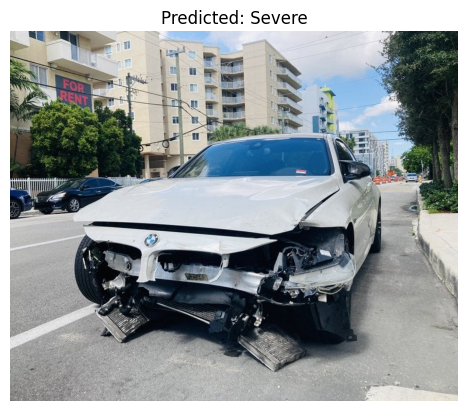

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# Load your uploaded image
img = Image.open("BMWSeverity.jpg")

# Define the same transform as training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Prepare image
img_tensor = transform(img).unsqueeze(0).to(device)

# Predict with ResNet50 CNN
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    prediction = torch.argmax(output, 1).item()

# Map class number to label
class_names = ['Minor', 'Moderate', 'Severe']

# Show result
plt.imshow(img)
plt.title(f"Predicted: {class_names[prediction]}")
plt.axis('off')
plt.show()



Made Up Model (adjusted SVM)

In [ ]:
import numpy as np
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import joblib
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to 224x224
    transforms.ToTensor(),          # Convert to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize like ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder
dataset_train = datasets.ImageFolder('/content/Car_Damage_Severity_Dataset/data3a/training', transform=transform)
dataset_val   = datasets.ImageFolder('/content/Car_Damage_Severity_Dataset/data3a/validation', transform=transform)

#ConcatDataset
combined_dataset = ConcatDataset([dataset_train, dataset_val])

#combined dataset
print(f"Number of images in combined dataset: {len(combined_dataset)}")
print(f"Class names: {dataset_train.classes}")


Number of images in combined dataset: 1631
Class names: ['01-minor', '02-moderate', '03-severe']


In [ ]:
def extract_hog_features(image, resize_shape=(128, 64)):
    image_resized = resize(image, resize_shape)  # Resize image
    gray_image = rgb2gray(image_resized)  # grayscale
    features, _ = hog(
        gray_image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    return features

In [ ]:
hog_features = []
labels = []
for img, label in tqdm(combined_dataset, desc="Extracting HOG features"):

    img_numpy = img.numpy().transpose(1, 2, 0)
    # Extract HOG
    features = extract_hog_features(img_numpy)
    hog_features.append(features)
    labels.append(label)



Extracting HOG features: 100%|██████████| 1631/1631 [00:54<00:00, 29.92it/s]


In [ ]:
X = np.array(hog_features)
y = np.array(labels)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
svm_model = SVC(kernel='linear', C=1.0, probability=True)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [ ]:
train_accuracy = svm_model.score(X_train, y_train)
val_accuracy = svm_model.score(X_val, y_val)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Training Accuracy: 100.00%
Validation Accuracy: 49.54%


In [ ]:
joblib.dump(svm_model, '/content/svm_hog_car_damage_model.pkl')
joblib.dump(scaler, '/content/hog_scaler.pkl')  # Save the scaler for later use


['/content/hog_scaler.pkl']

Testing SVM

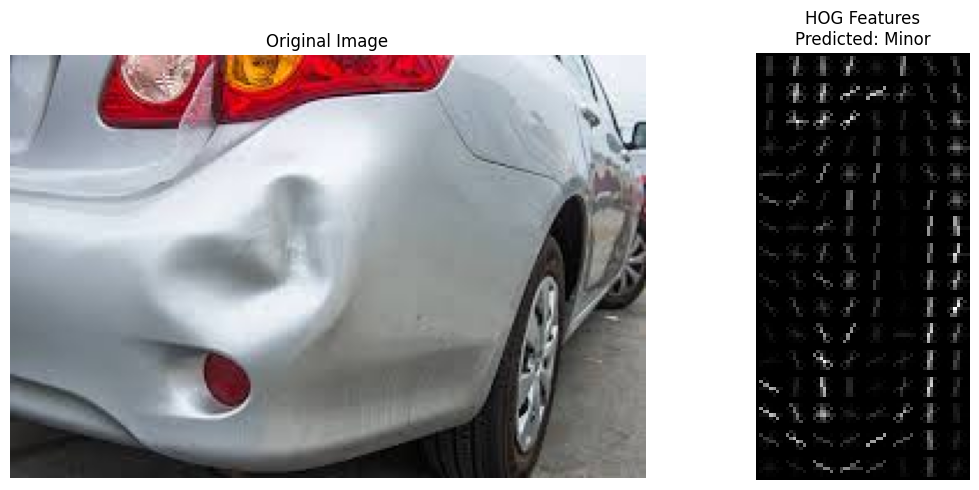

In [ ]:
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.feature import hog
import matplotlib.pyplot as plt
import joblib
import numpy as np

class_names = ['Minor', 'Moderate', 'Severe']

uploaded_image_path = '/content/Cars.jpg'

image = imread(uploaded_image_path)
image_resized = resize(image, (128, 64))  # HOG standard input size
gray = rgb2gray(image_resized)

# HOG
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)

X_test = scaler.transform([features])

# Load model
svm_model = joblib.load('/content/svm_hog_car_damage_model.pkl')
y_pred = svm_model.predict(X_test)
predicted_label = class_names[y_pred[0]]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title(f"HOG Features\nPredicted: {predicted_label}")
plt.axis('off')

plt.tight_layout()
plt.show()
